In [1]:
import numpy as np
from astropy import units as u
from astropy.io import fits
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from spectral_cube import SpectralCube
import regions
from astropy.wcs import WCS
from astropy.table import Table

from astroquery.vizier import Vizier

%cd /blue/adamginsburg/savannahgramze/cloudc/lactea-filament/lactea-filament
import cutout_manager as cm
%cd /blue/adamginsburg/savannahgramze/proposals/sagittariusE

/blue/adamginsburg/savannahgramze/cloudc/lactea-filament/lactea-filament
/blue/adamginsburg/savannahgramze/proposals/sagittariusE


In [2]:
viz = Vizier()

viz.ROW_LIMIT = -1  # to get all rows
# catalog to query: J/ApJS/212/1/table2
cat = viz.get_catalogs("J/ApJS/212/1")[0]

In [3]:
cat

WISE,Cl,GLON,GLAT,Rad,Vi1,DV1,Ref,Name,GLONs,GLATs,Vm1,Mol,Dist,_RA.icrs,_DE.icrs
,,deg,deg,arcsec,km / s,km / s,,,deg,deg,km / s,,kpc,deg,deg
str15,str1,float32,float32,int16,float32,float32,str2,str21,float32,float32,float32,str5,float32,float64,float64
G000.003+00.127,K,0.004,0.128,206,-5.5,36.3,87,,--,--,--,,--,266.2826,-28.8660
G000.008+00.036,Q,0.009,0.036,24,--,--,,,--,--,--,,--,266.3753,-28.9097
G000.025-00.232,Q,0.026,-0.231,46,--,--,,,--,--,--,,--,266.6460,-29.0341
G000.029-00.090,Q,0.030,-0.089,31,--,--,,,--,--,--,,--,266.5097,-28.9569
G000.041+00.021,Q,0.041,0.021,20,--,--,,,--,--,--,,--,266.4089,-28.8902
G000.043+00.013,Q,0.044,0.014,15,--,--,,,--,--,--,,--,266.4175,-28.8913
G000.052-00.205,Q,0.053,-0.205,18,--,--,,,--,--,--,,--,266.6366,-28.9975
G000.079-00.211,Q,0.080,-0.210,66,--,--,,,--,--,--,,--,266.6575,-28.9771


In [4]:
cat_pos = SkyCoord(ra=cat['_RA.icrs'], dec=cat['_DE.icrs'], unit=(u.deg, u.deg), frame='icrs')

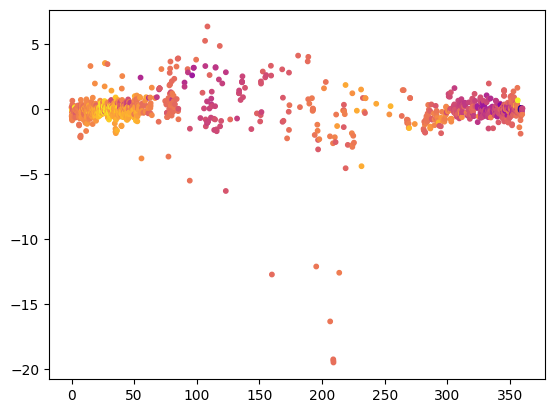

In [5]:
plt.scatter(cat_pos.galactic.l, cat_pos.galactic.b, s=10, c=cat['Vi1'], cmap='plasma')

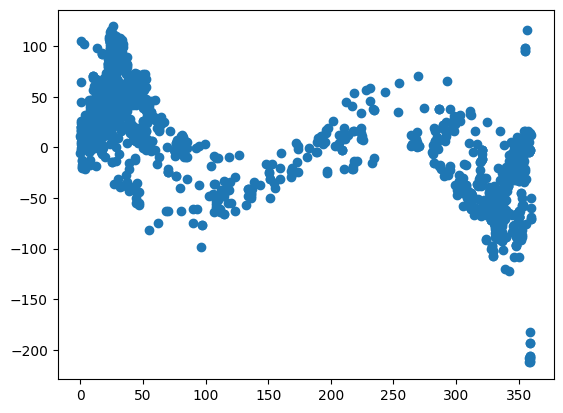

In [6]:
plt.scatter(cat_pos.galactic.l, cat['Vi1'])

In [ ]:
ls /orange/adamginsburg/galactic_plane_surveys/dame2001/

COGAL_all_interp.fits         ipython_log_2022-05-01.py
COGAL_all_interp_smooth.fits  ipython_log_2022-05-02.py
DameMomentMasked.ipynb


In [209]:
fn_CO10_broke = '/orange/adamginsburg/galactic_plane_surveys/dame2001/COGAL_all_interp_smooth.fits'
fn_CO10 = '/orange/adamginsburg/cmz/DataSetVisualizations/DHT02_Center_interp.fits'
#'/orange/adamginsburg/cmz/DataSetVisualizations/DHT02_Center_interp.fits'
#'/orange/adamginsburg/galactic_plane_surveys/dame2001/COGAL_all_interp.fits'
cube_CO10 = SpectralCube.read(fn_CO10)
cube_CO10_broke = SpectralCube.read(fn_CO10_broke)
#coord_ctr = SkyCoord(0, 0, unit=(u.deg, u.deg), frame='galactic')
#w_ctr = 12*u.deg
#l_ctr = 2*u.deg
# box that goes from -7 to 25 in glon
# the center is at 25-7/2 = 9
# the width is 25-(-7) = 32
# the height is 2 deg
w_ctr = 34*u.deg
l_ctr = 2*u.deg
coord_ctr = SkyCoord(8, 0, unit=(u.deg, u.deg), frame='galactic')
reg_ctr = regions.RectangleSkyRegion(center=coord_ctr, width=w_ctr, height=l_ctr)
ctr_cutout = cube_CO10.subcube_from_regions([reg_ctr])#, velocity_convention='radio', rest_value=115.2712*u.GHz)
ctr_cutout_broke = cube_CO10_broke.subcube_from_regions([reg_ctr])#, velocity_convention='radio', rest_value=115.2712*u.GHz)

In [233]:
ctr_cutout_broke.spectral_axis

<Quantity [-319.8, -318.5, -317.2, -315.9, -314.6, -313.3, -312. , -310.7,
           -309.4, -308.1, -306.8, -305.5, -304.2, -302.9, -301.6, -300.3,
           -299. , -297.7, -296.4, -295.1, -293.8, -292.5, -291.2, -289.9,
           -288.6, -287.3, -286. , -284.7, -283.4, -282.1, -280.8, -279.5,
           -278.2, -276.9, -275.6, -274.3, -273. , -271.7, -270.4, -269.1,
           -267.8, -266.5, -265.2, -263.9, -262.6, -261.3, -260. , -258.7,
           -257.4, -256.1, -254.8, -253.5, -252.2, -250.9, -249.6, -248.3,
           -247. , -245.7, -244.4, -243.1, -241.8, -240.5, -239.2, -237.9,
           -236.6, -235.3, -234. , -232.7, -231.4, -230.1, -228.8, -227.5,
           -226.2, -224.9, -223.6, -222.3, -221. , -219.7, -218.4, -217.1,
           -215.8, -214.5, -213.2, -211.9, -210.6, -209.3, -208. , -206.7,
           -205.4, -204.1, -202.8, -201.5, -200.2, -198.9, -197.6, -196.3,
           -195. , -193.7, -192.4, -191.1, -189.8, -188.5, -187.2, -185.9,
           -184.6, -183.3

In [210]:
ls -l /orange/adamginsburg/cmz/dameCO/

total 7924
-rw-r--r-- 1 adamginsburg adamginsburg 8112960 Apr  3  2025 DHT02_Center_interp.fits


In [211]:
#cube_CO10.moment0().quicklook()

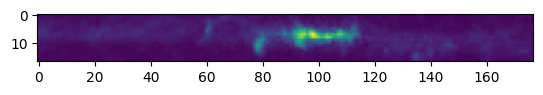

In [212]:
mom0 = ctr_cutout.moment0()
mom0.quicklook()

In [213]:
cat_ctr = cat[reg_ctr.contains(cat_pos.galactic, wcs=mom0.wcs)]
cat_pos_ctr = cat_pos[reg_ctr.contains(cat_pos.galactic, wcs=mom0.wcs)]

In [214]:
mask = (cat_ctr['Vi1'] < -60) | (cat_ctr['Vi1'] > 90) 
mask = mask & ((cat_ctr['GLON'] < 359.4) & (cat_ctr['GLON'] > 1))
#mask = #mask | ((cat_ctr['GLON'] < 10) & (cat_ctr['GLON'] > 50))
mask = mask & ~((cat_ctr['GLON'] > 10) & (cat_ctr['GLON'] < 300))
cat_fast = cat_ctr[mask]
cat_fast_pos = cat_pos_ctr[mask]

In [260]:
mask_sgre = (cat_ctr['GLON'] < 359.4) & (cat_ctr['GLON'] > 1) & (cat_ctr['Vi1'] < -100)
cat_sgre = cat_ctr[mask_sgre]
cat_sgre_pos = cat_pos_ctr[mask_sgre]

In [261]:
cat_sgre

WISE,Cl,GLON,GLAT,Rad,Vi1,DV1,Ref,Name,GLONs,GLATs,Vm1,Mol,Dist,_RA.icrs,_DE.icrs
,,deg,deg,arcsec,km / s,km / s,,,deg,deg,km / s,,kpc,deg,deg
str15,str1,float32,float32,int16,float32,float32,str2,str21,float32,float32,float32,str5,float32,float64,float64
G358.530+00.055,K,358.530,0.056,42,-212.6,27.1,82,,--,--,--,,8.5,265.4640,-30.1584
G358.552-00.026,K,358.552,-0.025,42,-208.5,20.4,82,,--,--,--,,8.5,265.5570,-30.1825
G358.616-00.077,K,358.616,-0.076,42,-212.6,21.5,82,,--,--,--,,8.5,265.6461,-30.1549
G358.652-00.079,K,358.652,-0.078,42,-211.2,19.4,82,,--,--,--,,8.5,265.6700,-30.1254
G358.680-00.088,K,358.680,-0.087,42,-208.3,19.9,82,,--,--,--,,8.5,265.6959,-30.1063
G358.694-00.076,K,358.694,-0.075,42,-207.8,19.5,82,,--,--,--,,8.5,265.6926,-30.0881
G358.720+00.010,K,358.720,0.011,42,-206.1,23.7,82,,--,--,--,,8.5,265.6239,-30.0207
G358.787+00.061,K,358.787,0.062,60,-206.6,50.5,89,,--,--,--,,8.5,265.6146,-29.9369


In [216]:
tbl_reid = Table.read('reid.txt', format='ascii', delimiter='&')
tbl_reid['coord_icrs'] = SkyCoord(ra=tbl_reid['RAJ2000'], dec=tbl_reid['DEJ2000'], unit=(u.hourangle, u.deg), frame='icrs')
tbl_reid['coord_reid'] = [c.split(',') for c in tbl_reid['Reid']] #tbl_reid['Reid'].str.split(',')
tbl_reid['coord_reid'] = [SkyCoord(float(c[0])*u.deg, float(c[1])*u.deg, frame='galactic') for c in tbl_reid['coord_reid']]
tbl_reid['coord_gal'] = tbl_reid['coord_icrs'].galactic
tbl_reid['Reid_VLSR'] = tbl_reid['Reid_VLSR'].astype(float) * u.km/u.s
tbl_reid['HRDS_VLSR'] = tbl_reid['Reid_VLSR'].astype(float) * u.km/u.s
tbl_reid

HRDS,RAJ2000,DEJ2000,Reid,Reid_sep,Reid_VLSR,HRDS_VLSR,coord_icrs,coord_reid,coord_gal
,,,,,km / s,km2 / s2,"deg,deg","deg,deg","deg,deg"
str14,str10,str9,str57,float64,float64,float64,SkyCoord,SkyCoord,SkyCoord
G009.682+0.206,18 06 20.0,-20 28 03,"9.621176471063594,0.1957935053947236,5.154639023221231",0.06160473901846092,2.0,2.0,"271.5833333333333,-20.467499999999998","9.621176471063594,0.1957935053947236","9.681955017251148,0.20589743614171907"
G010.473+0.028,18 08 39.6,-19 51 54,"10.47227523154777,0.027186927300818703,8.547008642800947",0.005472016993518135,69.0,69.0,"272.16499999999996,-19.865000000000002","10.47227523154777,0.027186927300818703","10.473981025064234,0.02198169983535988"
G010.638-0.434,18 10 41.9,-19 56 30,"10.623443843526005,-0.3831828909830318,4.950494877135871",0.05348405875352318,-3.0,-3.0,"272.6745833333333,-19.941666666666666","10.623443843526005,-0.3831828909830318","10.638618261810521,-0.43447489614964907"
G023.661-0.252,18 35 18.9,-08 21 35,"23.706481409035383,-0.19808948789577205,6.211180184009904",0.07074613728359502,73.0,73.0,"278.82874999999996,-8.359722222222222","23.706481409035383,-0.19808948789577205","23.660829382607087,-0.2521313958447477"
G024.739+0.083,18 36 07.1,-07 14 55,"24.78978446004424,0.08328615497898861,6.666666401757143",0.05088217319113222,111.0,111.0,"279.02958333333333,-7.248611111111111","24.78978446004424,0.08328615497898861","24.738918760696897,0.08236236001320926"


In [354]:
coord_sgrb2m = SkyCoord(ra='17 47 20.2000', dec='-28 23 6.00', unit=(u.hourangle, u.deg), frame='icrs')
coord_g06 = SkyCoord(ra='17 47 14.6261', dec='-28 26 51.65', unit=(u.hourangle, u.deg), frame='icrs')
v_sgrb2m = 58*u.km/u.s
v_g06 = 63*u.km/u.s

cat_gc = [(coord_sgrb2m, v_sgrb2m), (coord_g06, v_g06)]

In [355]:
def threekpx(x):
    return -0.5*x+305

/scratch/local/14950366/ipykernel_1090660/1564641548.py:9: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(cat_sgre_pos.galactic.l.wrap_at(180*u.deg).value, cat_sgre['Vi1'], s=10, c='orange', marker='o', facecolors='none', lw=2, transform=ax.get_transform('world'), label='Sgr E')
/scratch/local/14950366/ipykernel_1090660/1564641548.py:10: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter([c.galactic.l.wrap_at(180*u.deg).value for c, v in cat_gc], [v.value for c, v in cat_gc], s=20, c='purple', marker='D', facecolors='none', lw=2, transform=ax.get_transform('world'), label='CMZ')


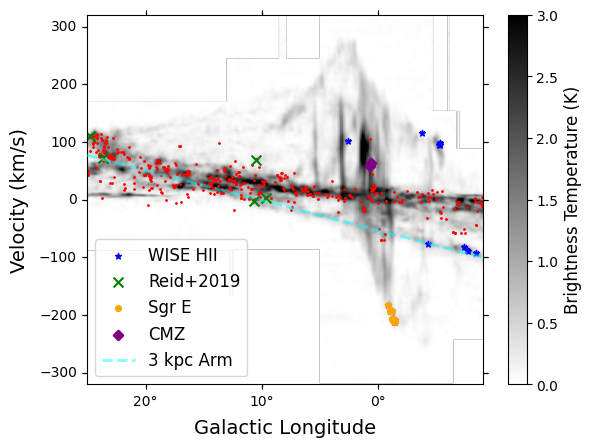

In [360]:
ax = plt.subplot(projection=pv_broke.wcs)
im = ax.imshow(pv_broke.data, aspect='auto', cmap='gray_r', vmin=0, vmax=3)
ax.coords[0].set_major_formatter('d:dd')
axb = ax.coords[1]
#axb.set_format_unit(u.km/u.s)
ax.scatter(cat_pos_ctr.galactic.l.wrap_at(180*u.deg).value, cat_ctr['Vi1'], s=1, c='red', transform=ax.get_transform('world'))
ax.scatter(cat_fast_pos.galactic.l.wrap_at(180*u.deg).value, cat_fast['Vi1'], s=20, c='blue', marker='*', transform=ax.get_transform('world'), label='WISE HII')
ax.scatter(tbl_reid['coord_gal'].l.wrap_at(180*u.deg).value, tbl_reid['Reid_VLSR'], s=50, c='green', marker='x', transform=ax.get_transform('world'), label='Reid+2019')
ax.scatter(cat_sgre_pos.galactic.l.wrap_at(180*u.deg).value, cat_sgre['Vi1'], s=10, c='orange', marker='o', facecolors='none', lw=2, transform=ax.get_transform('world'), label='Sgr E')
ax.scatter([c.galactic.l.wrap_at(180*u.deg).value for c, v in cat_gc], [v.value for c, v in cat_gc], s=20, c='purple', marker='D', facecolors='none', lw=2, transform=ax.get_transform('world'), label='CMZ')
cbar = plt.colorbar(im, ax=ax, orientation='vertical', label='Brightness Temperature (K)')
cbar.set_label('Brightness Temperature (K)', fontsize=12)
ax.set_xlabel('Galactic Longitude', fontsize=14)
ax.set_ylabel('Velocity (km/s)', fontsize=14)
#ax.text(0.8, 0.3, 'Far Dust Lane', transform=ax.transAxes, fontsize=12, va='top', ha='center', rotation=30)
#ax.text(0.15, 1, 'Near Dust Lane', transform=ax.transAxes, fontsize=12, va='top', ha='center', rotation=30)
xlims = ax.get_xlim()
ylims = ax.get_ylim()
ax.plot([xlims[0], xlims[1]], [threekpx(xlims[0]), threekpx(xlims[1])], c='cyan', ls='--', lw=2, label='3 kpc Arm', alpha=0.5)
#ax.text(0.2, 0.37, '3 kpc Arm', transform=ax.transAxes, fontsize=12, va='bottom', ha='center', color='k', alpha=1)
ax.set_xlim(xlims)
ax.set_ylim(ylims)
plt.legend(loc='lower left', fontsize=12)

plt.savefig('pvdiagram_targets.pdf', bbox_inches='tight')

In [14]:
table_hii_parameters = Table.read('/blue/adamginsburg/savannahgramze/proposals/sagittariusE/sgre/HIIregParameteres.txt', format='ascii')
parameters_RA = table_hii_parameters['RAh'] + table_hii_parameters['RAm']/60 + table_hii_parameters['RAs']/3600
parameters_Dec = table_hii_parameters['DEd'] + table_hii_parameters['DEm']/60 + table_hii_parameters['DEs']/3600
table_hii_parameters['RA'] = parameters_RA
table_hii_parameters['Dec'] = -1*parameters_Dec
table_hii_parameters['coord'] = SkyCoord(parameters_RA, -1*parameters_Dec, frame='icrs', unit=(u.hourangle, u.deg))

targets = [
    "G358.720+00.010",
    "G358.600-00.058",
    "G358.643-00.035",
    "G358.652-00.079",
    "G358.680-00.088",
    "G358.684-00.117",
    "G358.694-00.076",
    "G358.787+00.061",
    "G358.802-00.012",
    "G358.844+00.026",
    "G359.161-00.038",
]

for target in targets:
    match = table_hii_parameters['Name'] == target
    coord = table_hii_parameters['coord'][match][0]
    print(target, coord)

G358.720+00.010 <SkyCoord (ICRS): (ra, dec) in deg
    (265.62416667, -30.02055556)>
G358.600-00.058 <SkyCoord (ICRS): (ra, dec) in deg
    (265.61791667, -30.15861111)>
G358.643-00.035 <SkyCoord (ICRS): (ra, dec) in deg
    (265.62, -30.11083333)>
G358.652-00.079 <SkyCoord (ICRS): (ra, dec) in deg
    (265.67333333, -30.12555556)>
G358.680-00.088 <SkyCoord (ICRS): (ra, dec) in deg
    (265.70333333, -30.1075)>
G358.684-00.117 <SkyCoord (ICRS): (ra, dec) in deg
    (265.7275, -30.11805556)>
G358.694-00.076 <SkyCoord (ICRS): (ra, dec) in deg
    (265.6925, -30.08805556)>
G358.787+00.061 <SkyCoord (ICRS): (ra, dec) in deg
    (265.615, -29.93277778)>
G358.802-00.012 <SkyCoord (ICRS): (ra, dec) in deg
    (265.69583333, -29.96222222)>
G358.844+00.026 <SkyCoord (ICRS): (ra, dec) in deg
    (265.685, -29.9075)>
G359.161-00.038 <SkyCoord (ICRS): (ra, dec) in deg
    (265.93875, -29.67277778)>


In [15]:
coord = SkyCoord(358.8, 0, unit=(u.deg, u.deg), frame='galactic')
l = 20*u.arcmin
w = 0.8*u.deg

rgb_dat, rgb_wcs = cm.get_cutout_glimpse_rgb(coord, l, w)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.093048363274339..2.467217201418719].


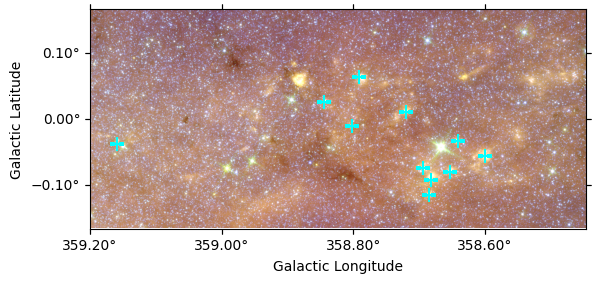

In [16]:
ax = plt.subplot(projection=rgb_wcs)
ax.imshow(rgb_dat, origin='lower')
#ax.scatter(table_hii_candidates['coord'].galactic.l, table_hii_candidates['coord'].galactic.b, transform=ax.get_transform('world'), s=50, edgecolor='red', facecolor='none', label='HII Candidates')
for target in targets:
    match = table_hii_parameters['Name'] == target
    im = ax.scatter(table_hii_parameters['coord'][match].galactic.l, table_hii_parameters['coord'][match].galactic.b, transform=ax.get_transform('world'), s=100, color='cyan', label=target, marker='+')
ax.coords[0].set_major_formatter('d.dd')
ax.coords[1].set_major_formatter('d.dd')
ax.set_xlabel('Galactic Longitude')
ax.set_ylabel('Galactic Latitude')
#plt.colorbar(im, label='VLSR1 (km/s)')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.093048363274339..2.467217201418719].
/scratch/local/14950366/ipykernel_1090660/3346763006.py:24: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax1.scatter(cat_sgre_pos.galactic.l.wrap_at(180*u.deg).value, cat_sgre['Vi1'], s=10, c='orange', marker='o', facecolors='none', lw=2, transform=ax1.get_transform('world'), label='Sgr E')
/scratch/local/14950366/ipykernel_1090660/3346763006.py:25: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax1.scatter([c.galactic.l.wrap_at(180*u.deg).value for c, v in cat_gc], [v.to(u.km/u.s).value for c, v in cat_gc], s=20, c='purple', marker='D', facecolors='none', lw=2, transform=ax1.get_transform('world'), label=

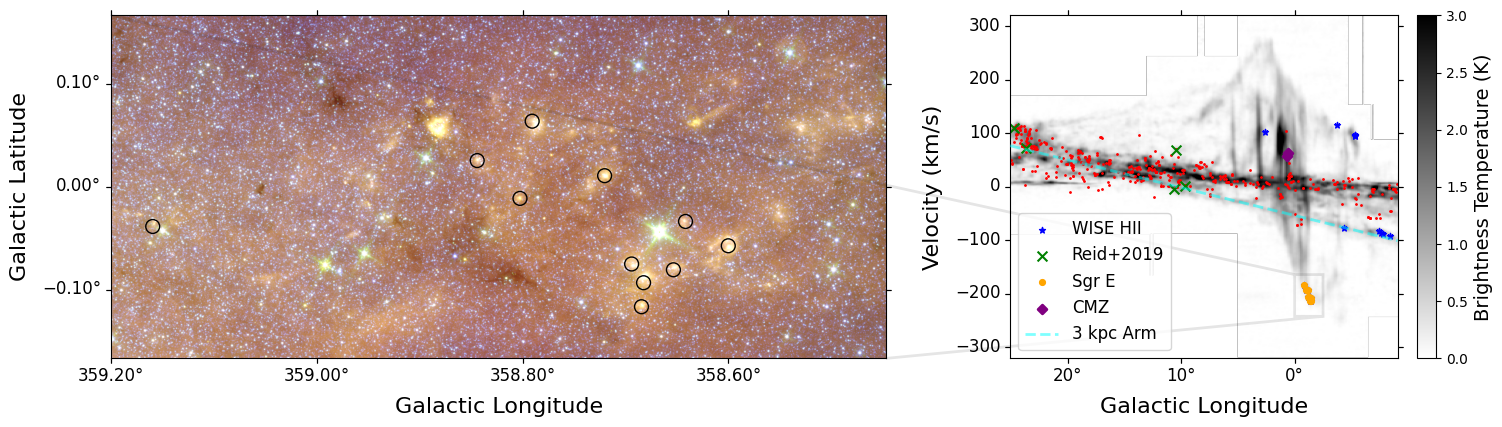

In [365]:
fig = plt.figure(figsize=(10, 5))

ax = plt.subplot(projection=rgb_wcs)
ax.imshow(rgb_dat, origin='lower')
#ax.scatter(table_hii_candidates['coord'].galactic.l, table_hii_candidates['coord'].galactic.b, transform=ax.get_transform('world'), s=50, edgecolor='red', facecolor='none', label='HII Candidates')
for target in targets:
    match = table_hii_parameters['Name'] == target
    im = ax.scatter(table_hii_parameters['coord'][match].galactic.l, table_hii_parameters['coord'][match].galactic.b, transform=ax.get_transform('world'), s=100, edgecolor='k', facecolor='none', label=target)
ax.coords[0].set_major_formatter('d.dd')
ax.coords[1].set_major_formatter('d.dd')
ax.set_xlabel('Galactic Longitude', fontsize=16)
ax.set_ylabel('Galactic Latitude', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)

#ax = plt.subplot(projection=pv.wcs)
ax1 = ax.inset_axes([1.16, 0., 0.5, 1], projection=pv_broke.wcs)
im = ax1.imshow(pv_broke.data, aspect='auto', cmap='gray_r', vmin=0, vmax=3)
ax1.coords[0].set_major_formatter('d:dd')
#axb = ax1.coords[1]
#axb.set_format_unit(u.km/u.s)
ax1.scatter(cat_pos_ctr.galactic.l.wrap_at(180*u.deg).value, cat_ctr['Vi1'], s=1, c='red', transform=ax1.get_transform('world'))
ax1.scatter(cat_fast_pos.galactic.l.wrap_at(180*u.deg).value, cat_fast['Vi1'], s=20, c='blue', marker='*', transform=ax1.get_transform('world'), label='WISE HII')
ax1.scatter(tbl_reid['coord_gal'].l.wrap_at(180*u.deg).value, tbl_reid['Reid_VLSR'], s=50, c='green', marker='x', transform=ax1.get_transform('world'), label='Reid+2019')
ax1.scatter(cat_sgre_pos.galactic.l.wrap_at(180*u.deg).value, cat_sgre['Vi1'], s=10, c='orange', marker='o', facecolors='none', lw=2, transform=ax1.get_transform('world'), label='Sgr E')
ax1.scatter([c.galactic.l.wrap_at(180*u.deg).value for c, v in cat_gc], [v.to(u.km/u.s).value for c, v in cat_gc], s=20, c='purple', marker='D', facecolors='none', lw=2, transform=ax1.get_transform('world'), label='CMZ')
#plt.colorbar(im, ax=ax1, orientation='vertical', label='Brightness Temperature (K)')
ax1.set_xlabel('Galactic Longitude', fontsize=16)
ax1.set_ylabel('Velocity (km/s)', fontsize=16)
#ax1.text(0.8, 0.3, 'Far Dust Lane', transform=ax1.transAxes, fontsize=12, va='top', ha='center', rotation=30)
#ax1.text(0.15, 1, 'Near Dust Lane', transform=ax1.transAxes, fontsize=12, va='top', ha='center', rotation=30)
xlims = ax1.get_xlim()
ylims = ax1.get_ylim()
ax1.plot([xlims[0], xlims[1]], [threekpx(xlims[0]), threekpx(xlims[1])], c='cyan', ls='--', lw=2, label='3 kpc Arm', alpha=0.5)
#ax1.text(0.2, 0.37, '3 kpc Arm', transform=ax1.transAxes, fontsize=12, va='bottom', ha='center', color='k', alpha=1)
ax1.set_xlim(xlims)
ax1.set_ylim(ylims)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.legend(loc='lower left', fontsize=12)

#plt.savefig('pvdiagram_targets.pdf', bbox_inches='tight')
cax = ax1.inset_axes([1.05, 0, 0.05, 1])
cbar = plt.colorbar(im, cax=cax, orientation='vertical', label='Brightness Temperature (K)')
cbar.ax.yaxis.label.set_size(14)

ax1.indicate_inset(inset_ax=ax, edgecolor='k', linewidth=2, bounds=[200, 60, 20, 60], alpha=0.1)
plt.savefig('targets_with_pvdiagram.pdf', bbox_inches='tight')

In [366]:
10**0.49

3.0902954325135905

In [337]:
rii_mask = (cat_fast['Vi1'] > -100) & (cat_fast['Vi1'] < 0)
cat_rii = cat_fast[rii_mask]
cat_rii_pos = cat_fast_pos[rii_mask]
cat_rii

WISE,Cl,GLON,GLAT,Rad,Vi1,DV1,Ref,Name,GLONs,GLATs,Vm1,Mol,Dist,_RA.icrs,_DE.icrs
,,deg,deg,arcsec,km / s,km / s,,,deg,deg,km / s,,kpc,deg,deg
str15,str1,float32,float32,int16,float32,float32,str2,str21,float32,float32,float32,str5,float32,float64,float64
G351.584-00.350,K,351.584,-0.350,80,-91.8,18.5,88,17220-3609,351.583,-0.350,-98.5,CS,--,261.3538,-36.2086
G352.234-00.152,K,352.234,-0.151,79,-88.6,20.0,82,,--,--,--,,--,261.5992,-35.5586
G352.393-00.066,K,352.393,-0.065,102,-87.0,33.7,88,17231-3520,352.394,-0.069,-90.2,CS,--,261.6206,-35.3787
G352.597-00.188,K,352.597,-0.188,118,-81.9,21.6,88,17242-3513,352.605,-0.183,-86.5,CS,--,261.8852,-35.2778
G355.680+00.006,K,355.680,0.007,163,-76.1,25.9,88,,--,--,--,,--,263.7279,-32.5933


/scratch/local/14950366/ipykernel_1090660/3209750382.py:7: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax1.scatter(cat_rii_pos.galactic.l.wrap_at(180*u.deg).value, cat_rii['Vi1']*1000, s=50, c='purple', marker='x', facecolors='none', lw=2, transform=ax.get_transform('world'), label='RII')


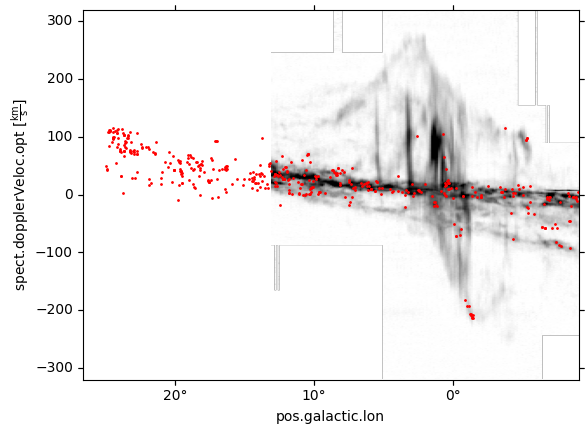

In [340]:
ax1 = plt.subplot(projection=pv.wcs)
im = ax1.imshow(pv.data, aspect='auto', cmap='gray_r', vmin=0, vmax=3)
ax1.coords[0].set_major_formatter('d:dd')
axb = ax1.coords[1]
axb.set_format_unit(u.km/u.s)
ax1.scatter(cat_pos_ctr.galactic.l.wrap_at(180*u.deg).value, cat_ctr['Vi1']*1000, s=1, c='red', transform=ax1.get_transform('world'))
ax1.scatter(cat_rii_pos.galactic.l.wrap_at(180*u.deg).value, cat_rii['Vi1']*1000, s=50, c='purple', marker='x', facecolors='none', lw=2, transform=ax.get_transform('world'), label='RII')

In [279]:
mask_fast = (cat_fast['GLON'] > 2.5) & (cat_fast['GLON'] < 6.5) & (cat_fast['Vi1'] > 90)
cat_fast[mask_fast]

WISE,Cl,GLON,GLAT,Rad,Vi1,DV1,Ref,Name,GLONs,GLATs,Vm1,Mol,Dist,_RA.icrs,_DE.icrs
,,deg,deg,arcsec,km / s,km / s,,,deg,deg,km / s,,kpc,deg,deg
str15,str1,float32,float32,int16,float32,float32,str2,str21,float32,float32,float32,str5,float32,float64,float64
G002.614+00.133,K,2.614,0.133,60,102.4,25.7,88,17480-2636,2.613,0.134,96.1,CS,--,267.8012,-26.6285


In [285]:
mask_right = (cat_fast['GLON'] < 358) & (cat_fast['GLON'] > 345)
cat_right = cat_fast[mask_right]

In [286]:
fn_fast = '/orange/adamginsburg/galactic_plane_surveys/glimpse/GLM_00300+0000_mosaic_I4.fits'
fn_right = '/orange/adamginsburg/galactic_plane_surveys/glimpse/GLM_35400+0000_mosaic_I4.fits'
fn_right_m = '/orange/adamginsburg/galactic_plane_surveys/glimpse/GLM_35700+0000_mosaic_I4.fits'
fn_right_mm = '/orange/adamginsburg/galactic_plane_surveys/glimpse/GLM_35100+0000_mosaic_I4.fits'

spit_I4 = cm.get_cutout(fn_fast, SkyCoord(cat_fast[mask_fast]['GLON'], cat_fast[mask_fast]['GLAT'], unit=(u.deg, u.deg), frame='galactic'), l=1*u.arcmin, w=1*u.arcmin)
#cm.get_cutout_rgb(SkyCoord(cat_fast[mask_fast]['GLON'], cat_fast[mask_fast]['GLAT'], unit=(u.deg, u.deg), frame='galactic'), l=30*u.arcmin, w=30*u.arcmin)

In [287]:
cat_fast[mask_fast]

WISE,Cl,GLON,GLAT,Rad,Vi1,DV1,Ref,Name,GLONs,GLATs,Vm1,Mol,Dist,_RA.icrs,_DE.icrs
,,deg,deg,arcsec,km / s,km / s,,,deg,deg,km / s,,kpc,deg,deg
str15,str1,float32,float32,int16,float32,float32,str2,str21,float32,float32,float32,str5,float32,float64,float64
G002.614+00.133,K,2.614,0.133,60,102.4,25.7,88,17480-2636,2.613,0.134,96.1,CS,--,267.8012,-26.6285


17480-2636
<SkyCoord (ICRS): (ra, dec) in deg
    (267.80117878, -26.62852966)>


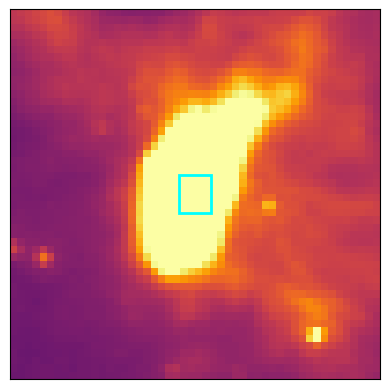

In [288]:
ax = plt.subplot(projection=spit_I4.wcs)
im = ax.imshow(spit_I4.data, origin='lower', cmap='inferno', vmin=0, vmax=250)
reg_fov = regions.RectangleSkyRegion(center=SkyCoord(cat_fast[mask_fast]['GLON'], cat_fast[mask_fast]['GLAT'], unit=(u.deg, u.deg), frame='galactic')[0], width=5.2*u.arcsec, height=6.2*u.arcsec)
reg_fov.to_pixel(spit_I4.wcs).plot(ax=ax, edgecolor='cyan', lw=2, facecolor='none')
print(cat_fast[mask_fast]['Name'][0])
print(SkyCoord(cat_fast[mask_fast]['GLON'], cat_fast[mask_fast]['GLAT'], unit=(u.deg, u.deg), frame='galactic')[0].icrs)
ax.coords[0].set_major_formatter('d:dd')
ax.coords[1].set_major_formatter('d:dd')

G351.584-00.350
<SkyCoord (ICRS): (ra, dec) in deg
    (261.35376878, -36.20861219)>


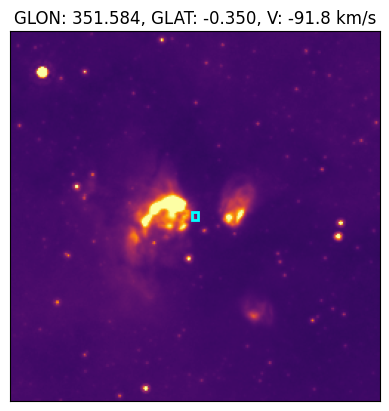

G352.234-00.152
<SkyCoord (ICRS): (ra, dec) in deg
    (261.59919313, -35.55857658)>


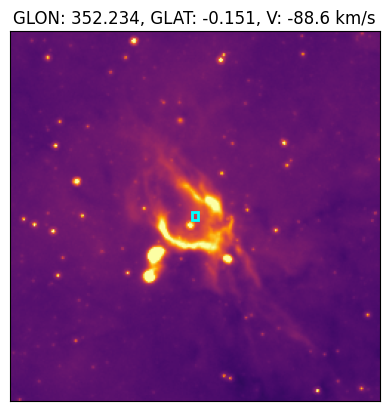

G352.393-00.066
<SkyCoord (ICRS): (ra, dec) in deg
    (261.62064359, -35.37865822)>


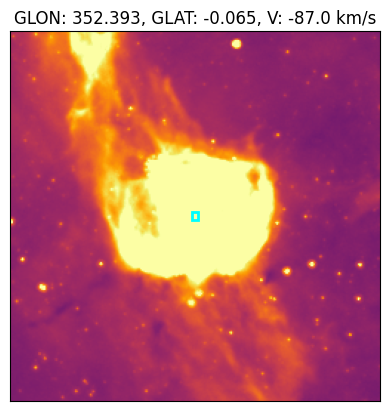

G352.597-00.188
<SkyCoord (ICRS): (ra, dec) in deg
    (261.88516572, -35.27785115)>


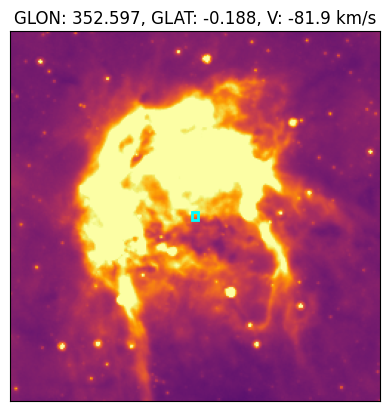

G354.670+00.252
<SkyCoord (ICRS): (ra, dec) in deg
    (262.82723333, -33.30670862)>


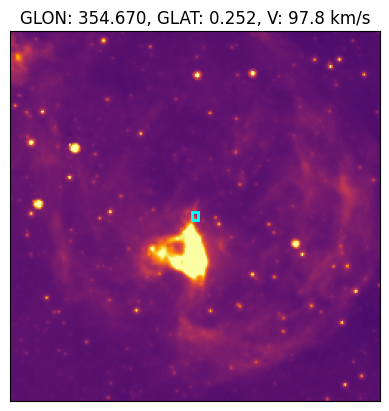

G354.672+00.246
<SkyCoord (ICRS): (ra, dec) in deg
    (262.83453825, -33.30834078)>


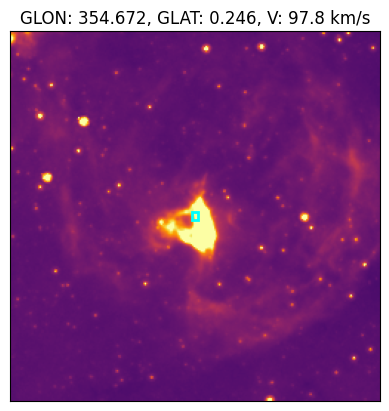

G354.714+00.288
<SkyCoord (ICRS): (ra, dec) in deg
    (262.81908144, -33.24964387)>


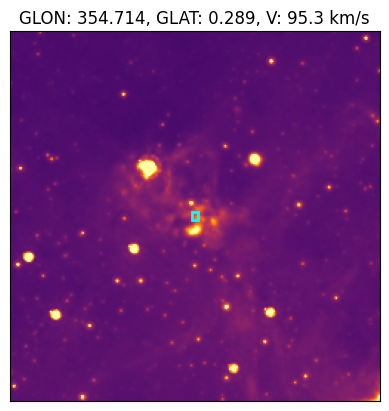

G354.727+00.302
<SkyCoord (ICRS): (ra, dec) in deg
    (262.81361308, -33.23109421)>


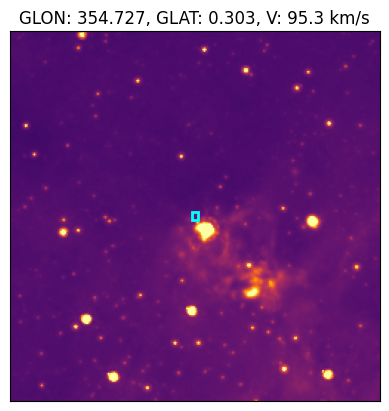

G355.680+00.006
<SkyCoord (ICRS): (ra, dec) in deg
    (263.72786755, -32.59332324)>


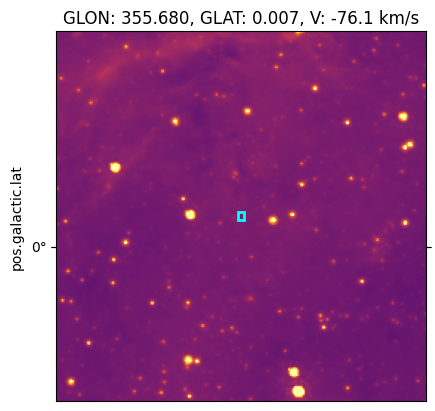

G356.230+00.670
<SkyCoord (ICRS): (ra, dec) in deg
    (263.42231863, -31.77161639)>


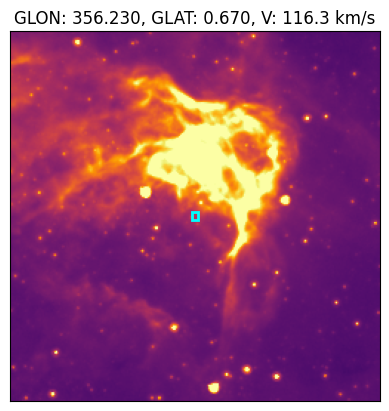

In [289]:
for obj in cat_right:
    try: 
        cutout = cm.get_cutout(fn_right, SkyCoord(obj['GLON'], obj['GLAT'], unit=(u.deg, u.deg), frame='galactic'), l=5*u.arcmin, w=5*u.arcmin)
    except:
        try: 
            cutout = cm.get_cutout(fn_right_m, SkyCoord(obj['GLON'], obj['GLAT'], unit=(u.deg, u.deg), frame='galactic'), l=5*u.arcmin, w=5*u.arcmin)
        except:
            cutout = cm.get_cutout(fn_right_mm, SkyCoord(obj['GLON'], obj['GLAT'], unit=(u.deg, u.deg), frame='galactic'), l=5*u.arcmin, w=5*u.arcmin)

    ax = plt.subplot(projection=cutout.wcs)
    im = ax.imshow(cutout.data, origin='lower', cmap='inferno', vmin=0, vmax=250)
    reg_fov = regions.RectangleSkyRegion(center=SkyCoord(obj['GLON'], obj['GLAT'], unit=(u.deg, u.deg), frame='galactic'), width=5.2*u.arcsec, height=6.2*u.arcsec)
    reg_fov.to_pixel(cutout.wcs).plot(ax=ax, edgecolor='cyan', lw=2, facecolor='none')
    print(obj['WISE'])
    print(SkyCoord(obj['GLON'], obj['GLAT'], unit=(u.deg, u.deg), frame='galactic').icrs)
    ax.coords[0].set_major_formatter('d:dd')
    ax.coords[1].set_major_formatter('d:dd')
    ax.set_title(f"GLON: {obj['GLON']:.3f}, GLAT: {obj['GLAT']:.3f}, V: {obj['Vi1']:.1f} km/s")
    plt.show()

In [344]:
360-351

9

In [346]:
leng = 9*u.deg
dist = 8.2*u.kpc
leng_pc = leng.to(u.rad).value * dist
leng_pc

<Quantity 1.28805299 kpc>

In [347]:
leng = 2.6*u.deg
dist = 8.2*u.kpc
leng_pc = leng.to(u.rad).value * dist
leng_pc

<Quantity 0.3721042 kpc>

In [348]:
SkyCoord(0.6, 0, unit=(u.deg, u.deg), frame='galactic').icrs

<SkyCoord (ICRS): (ra, dec) in deg
    (266.76045258, -28.42358792)>